## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"
pert_path = project_dir / "2_noise_pert.py"

In [2]:
from calculate_metrics import calculate_metrics

In [3]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [4]:
# import case file
case_path = andes.get_case(test_case_dir / "wscc9_connected.xlsx")

In [5]:
# TDS Constants
STEP_TIME = 0.01 # 10 ms

In [6]:
ss_true = andes.load(case_path, setup=False)
add_idx = "PQ_1"
ss_true.add("Toggle", model="PQ", dev=add_idx, t=5.0) # add the load @ t=5s


ss_true.setup()
ss_true.config.warn_abnormal = 0
ss_true.PFlow.run()
#ss_true.REGF2.set("Tr",1,0.01)

ss_true.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss_true.TDS.config.fixt = 1 # fixed step size
ss_true.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss_true.TDS.config.no_tqdm = 1
ss_true.TDS.config.criteria = 1
ss_true.TDS.run()

True

## Run TDS & Initial Results

In [35]:
ss = andes.load(case_path, pert=pert_path)
ss.REGF2.set("Tr",1,0.005)
print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.005]
pert() applied at grid_t=0.0
pert() applied at grid_t=0.01
pert() applied at grid_t=0.02
pert() applied at grid_t=0.03
pert() applied at grid_t=0.04
pert() applied at grid_t=0.05
pert() applied at grid_t=0.06
pert() applied at grid_t=0.07
pert() applied at grid_t=0.08
pert() applied at grid_t=0.09
pert() applied at grid_t=0.1
pert() applied at grid_t=0.11
pert() applied at grid_t=0.12
pert() applied at grid_t=0.13
pert() applied at grid_t=0.14
pert() applied at grid_t=0.15
pert() applied at grid_t=0.16
pert() applied at grid_t=0.17
pert() applied at grid_t=0.18
pert() applied at grid_t=0.19
pert() applied at grid_t=0.2
pert() applied at grid_t=0.21
pert() applied at grid_t=0.22
pert() applied at grid_t=0.23
pert() applied at grid_t=0.24
pert() applied at grid_t=0.25
pert() applied at grid_t=0.26
pert() applied at grid_t=0.27
pert() applied at grid_t=0.28
pert() applied at grid_t=0.29
pert() applied at grid_t=0.3
pert() applied at grid_t=0.31
pert() applied at grid_t=0.32
pert()

System has been setup. Calling setup() twice is not allowed. To add devices, reload the case with setup=False, add devices, then call setup().


pert() applied at grid_t=0.5
pert() applied at grid_t=0.51
pert() applied at grid_t=0.52
pert() applied at grid_t=0.53
pert() applied at grid_t=0.54
pert() applied at grid_t=0.55
pert() applied at grid_t=0.56
pert() applied at grid_t=0.5700000000000001
pert() applied at grid_t=0.58
pert() applied at grid_t=0.59
pert() applied at grid_t=0.6
pert() applied at grid_t=0.61
pert() applied at grid_t=0.62
pert() applied at grid_t=0.63
pert() applied at grid_t=0.64
pert() applied at grid_t=0.65
pert() applied at grid_t=0.66
pert() applied at grid_t=0.67
pert() applied at grid_t=0.68
pert() applied at grid_t=0.6900000000000001
pert() applied at grid_t=0.7000000000000001
pert() applied at grid_t=0.71
pert() applied at grid_t=0.72
pert() applied at grid_t=0.73
pert() applied at grid_t=0.74
pert() applied at grid_t=0.75
pert() applied at grid_t=0.76
pert() applied at grid_t=0.77
pert() applied at grid_t=0.78
pert() applied at grid_t=0.79
pert() applied at grid_t=0.8
pert() applied at grid_t=0.81
p

True

In [36]:
def visualize_cf_noise(noisy, true, var, figsize=(6,4)):
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_title(f"{var}: Noisy vs. Noiseless Signal Inputs")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"{var} (p.u.)")

    # plot actual
    ax.plot(true.index, true, "s-", color="tab:blue",
                markersize=0.5, label="Noiseless Inputs", alpha=0.8)
    ax.plot(noisy.index, noisy, "s-", color="tab:orange",
                    markersize=0.5, label="Noisy Inputs", alpha=0.8)
    
    

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)


    plt.tight_layout()

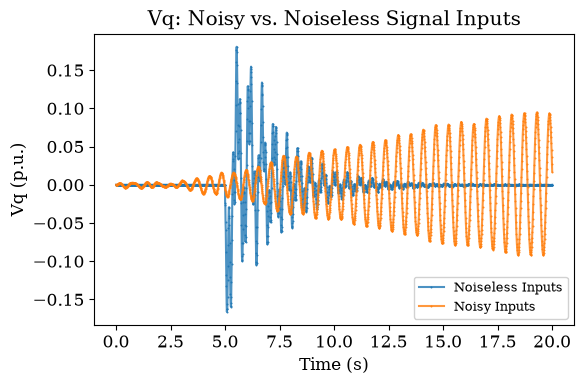

In [33]:
vq = ss.TDS.get_timeseries(ss.REGF2.vq)
vq_t = ss_true.TDS.get_timeseries(ss_true.REGF2.vq)

visualize_cf_noise(vq, vq_t, "Vq")

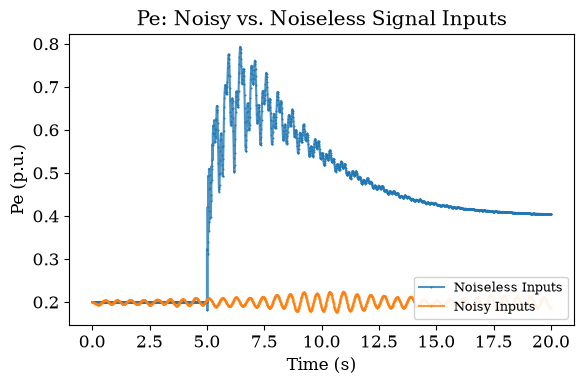

In [37]:
psen = ss.TDS.get_timeseries(ss.REGF2.Pe)
psen_t = ss_true.TDS.get_timeseries(ss_true.REGF2.Pe)

visualize_cf_noise(psen, psen_t, "Pe")

In [38]:
psen

,1
0.00,0.199931
0.01,0.199794
0.02,0.199685
0.03,0.199512
0.04,0.199271
...,...
19.96,0.185470
19.97,0.185580
19.98,0.185831
19.99,0.186282


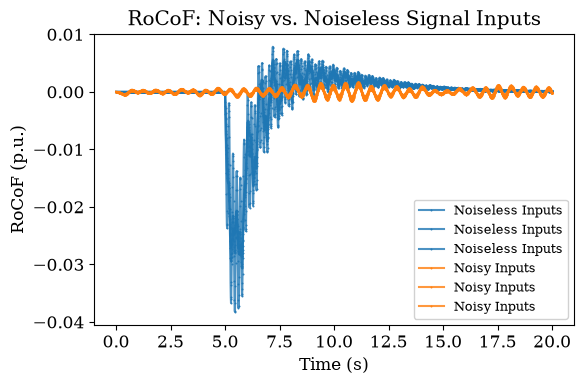

In [39]:
a1 = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
a2 = ss_true.TDS.get_timeseries(ss_true.BusROCOF.Wf_y)

visualize_cf_noise(a1, a2, "RoCoF")

## Metrics

In [40]:
metrics_df, h_series = calculate_metrics(ss, True)
metrics_df

ValueError: Length mismatch: Expected axis has 7 elements, new values have 3 elements

In [26]:
metrics_true, h_true = calculate_metrics(ss_true, True)

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/andes_env/lib/python3.11/site-packages/statsmodels/tools/eval_measures.py:40: RuntimeWarning: overflow encountered in square
  return np.mean((x1 - x2) ** 2, axis=axis)
/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/andes_env/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1)
H_t = h_series

plot_title = f"Nominal ({H_gfm}s) vs. Estimated Inertia"
ax.set_title(plot_title)
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (s)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:blue", markersize=1.8, label = f"$H_{{estimated}}$")

plt.axline((0, H_gfm), slope=0, color="orange", linestyle=":", label=f"$H_{{nominal}}$")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

#ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
#plt.xlim(0, 6)
#plt.ylim(-1, 50)
plt.tight_layout()

#plt.savefig(f'{out_dir}/1_testbench_figs/{plot_title}.png', dpi=300, bbox_inches='tight')

In [ ]:
visualize_cf_noise(h_series, h_true, "Estimated Inertia")

In [ ]:
ss_true.TDS.plot(ss.Bus.v)

# Temp

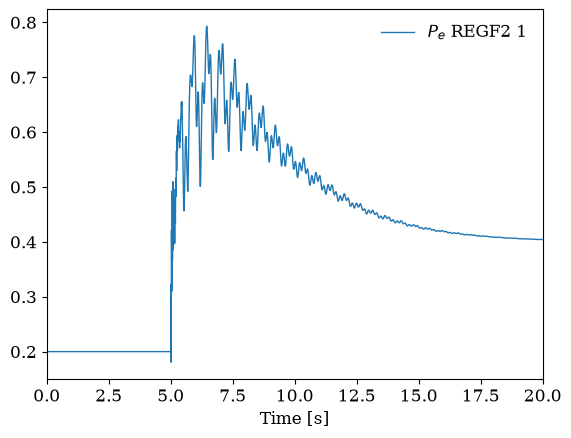

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [46]:
ss_true.TDS.plot(ss_true.REGF2.Pe)

In [14]:
from liu_inertia_estimation import calc_inertia

In [16]:
ss_true.TDS.get_timeseries(ss_true.BusROCOF.Wf_y).loc[:"BusROCOF_1"]

,BusROCOF_1,BusROCOF_2,BusROCOF_3
0.0000,0.000000,0.000000,0.000000
0.0100,0.000000,0.000000,0.000000
0.0200,0.000000,0.000000,0.000000
0.0300,0.000000,0.000000,0.000000
0.0400,0.000000,0.000000,0.000000
...,...,...,...
19.9691,0.000144,0.000106,0.000145
19.9791,0.000145,0.000102,0.000154
19.9891,0.000143,0.000099,0.000160
19.9991,0.000138,0.000096,0.000163


In [17]:
# get frequency, RoCoF, and power time-series. 
tds_df = pd.concat([ss_true.TDS.get_timeseries(ss_true.BusROCOF.f).loc[:,"BusROCOF_1"], 
                    ss_true.TDS.get_timeseries(ss_true.BusROCOF.Wf_y).loc[:,"BusROCOF_1"], 
                    ss_true.TDS.get_timeseries(ss_true.REGF2.Pe)],
                    axis=1)

tds_df.columns = ["f", "df/dt", "p"]

tds_df

,f,df/dt,p
0.0000,1.000000,0.000000,0.200000
0.0100,1.000000,0.000000,0.200000
0.0200,1.000000,0.000000,0.200000
0.0300,1.000000,0.000000,0.200000
0.0400,1.000000,0.000000,0.200000
...,...,...,...
19.9691,0.988125,0.000144,0.404128
19.9791,0.988127,0.000145,0.404104
19.9891,0.988128,0.000143,0.404099
19.9991,0.988129,0.000138,0.404111


In [18]:
M_df = calc_inertia(tds_df, 20)
M_ser = M_df.loc[:,"M"]

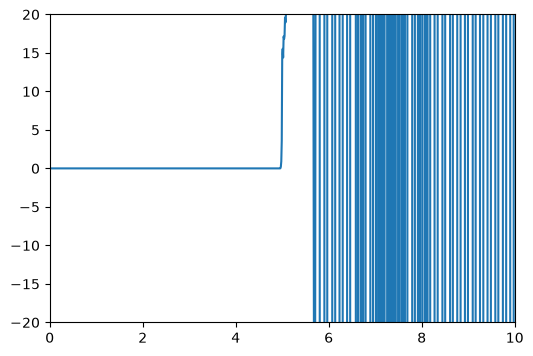

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, 10)
ax.set_ylim(-20, 20)
ax.plot(M_ser.index, M_ser)

(0.0, 20.0)

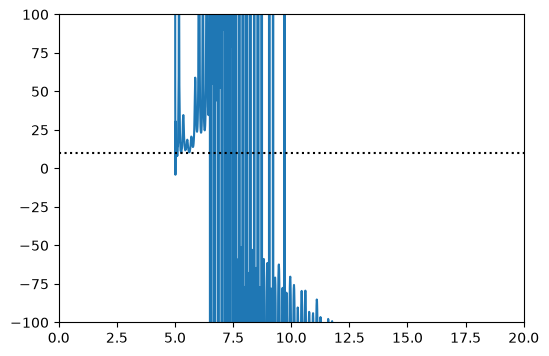

In [13]:
from algebraic_inertia_estimation import calc_inertia_algebraic
ser = calc_inertia_algebraic(tds_df, 0.2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ser.index, ser)
ax.axline((0, 10), slope=0, color="black", linestyle=":")
ax.set_ylim(-100, 100)
ax.set_xlim(0, 20)